In [ ]:
# Fig. 3| Compartment-specific vulnerability of CA1 along superficial–deep and proximal–distal axes in hippocampal sclerosis.

## Fig3b-统计

## Fig3g-GO

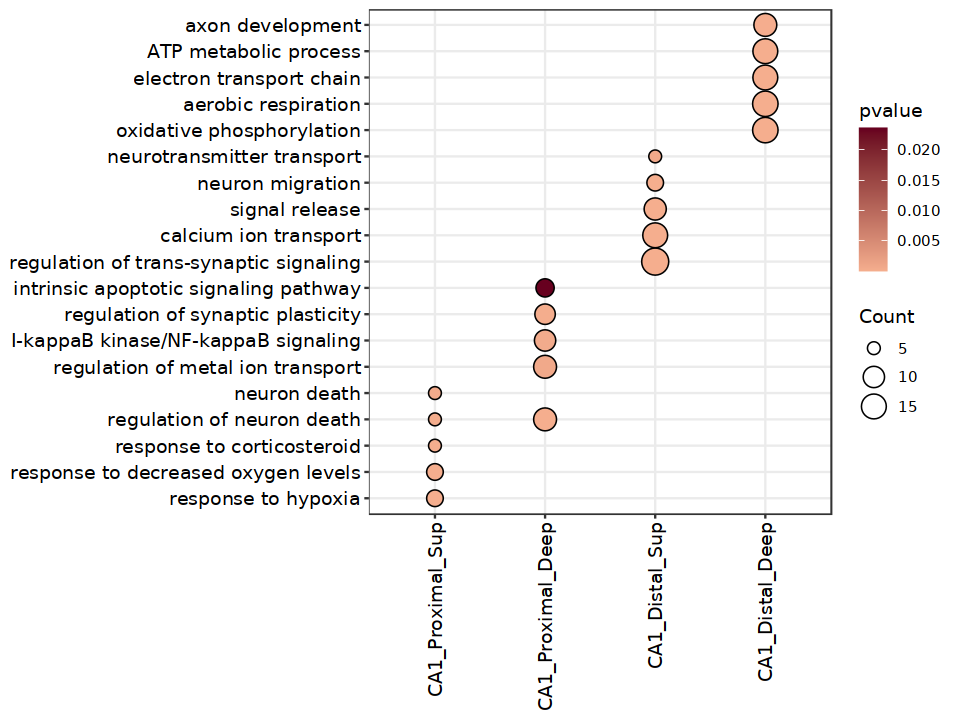

In [24]:
options(repr.plot.width = 50)
GO$Description = factor(GO$Description,levels = unique(GO$Description))

p1 = ggplot(GO, aes(cluster, Description)) +
  geom_point(aes(fill = pvalue, size = Count), shape = 21) +
  theme_bw() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
    axis.text = element_text(color = 'black', size = 11)
  ) +
  scale_fill_gradient(low = "#F5AE8E", high = "#67001F") + # 红色渐变
  scale_size(range = c(3,7)) + # 设置点的尺寸范围，最小直径为5，最大直径为10
  labs(x = NULL, y = NULL)

options(repr.plot.width=8, repr.plot.height=6)
p1

## Fig3h-pathway_score

In [2]:
seuobj = readRDS('/data/users/liuyuyang/online/07.ReAnalysis/03.cellbin/03_CA1_4subregion/02_all/cellbin.all.af_scale.rds')
seuobj = subset(seuobj,area %in% c('CA1_Proximal_Sup','CA1_Distal_Sup','CA1_Proximal_Deep','CA1_Distal_Deep')  )
seuobj = subset(seuobj,CellType == 'EX_CA1'  )
seuobj$group = gsub('_.*$','',seuobj$group)

In [3]:
 term.gene = c('CCL2','FOS','EGR1','CLU','NTRK2','CRLF1','NUPR1','JUN','MT3','HIPK2','SORL1','MAG')
  term.gene = as.list(data.frame(term.gene = term.gene ),stringsAsFactors = F)
  if(length(term.gene$term.gene)!=1){
  seuobj <- AddModuleScore(
  object = seuobj,
  features = term.gene,
  assay = "RNA",#"Spatial",
  ctrl = length(unlist(term.gene)), #默认值是100
  name = 'NeuronDeath'
  )}

In [4]:
gp_color <- c("#8dc7c2", "#e94c5f")
names(gp_color) = c('Normal','HS')

In [5]:
seuobj$area = factor(seuobj$area,levels = c('CA1_Proximal_Sup','CA1_Proximal_Deep','CA1_Distal_Sup','CA1_Distal_Deep') )
seuobj$group = factor(seuobj$group,levels = c('Normal','HS') )



In [51]:
meta = readRDS('/data/users/liuyuyang/online/07.ReAnalysis/03.cellbin/03_CA1_4subregion/cellbin.af_NeuronDeath_Score.metadata.rds')

In [54]:
head(meta)

,orig.ident,nCount_RNA,nFeature_RNA,nCount_Spatial,nFeature_Spatial,percent.mt,cellid,rx,ry,CellType,area,area_m,chip_id,Group,group,NeuronDeath1
,<chr>,<dbl>,<int>,<dbl>,<int>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<fct>,<chr>,<chr>,<chr>,<fct>,<dbl>
HS22_94,Spatial,1747,951,1747,951,9.902690,2805-13856,-13979.75,-2103.193,EX_CA1,CA1_Proximal_Sup,CA1,HS22,Normal,Normal,0.5102371
HS22_108,Spatial,309,210,309,210,11.326861,2805-13172,-13337.00,-1869.252,EX_CA1,CA1_Proximal_Sup,CA1,HS22,Normal,Normal,0.7521339
HS22_120,Spatial,865,503,865,503,6.705202,2810-19631,-19408.18,-4073.661,EX_CA1,CA1_Proximal_Sup,CA1,HS22,Normal,Normal,0.5166799
HS22_161,Spatial,736,501,736,501,14.266304,2827-11668,-11931.22,-1334.180,EX_CA1,CA1_Proximal_Deep,CA1,HS22,Normal,Normal,0.2273400
HS22_183,Spatial,721,438,721,438,9.986130,2823-18297,-18159.08,-3605.190,EX_CA1,CA1_Proximal_Sup,CA1,HS22,Normal,Normal,0.9883559
HS22_186,Spatial,459,322,459,322,12.200436,2827-13714,-13853.84,-2033.953,EX_CA1,CA1_Proximal_Sup,CA1,HS22,Normal,Normal,0.3351326


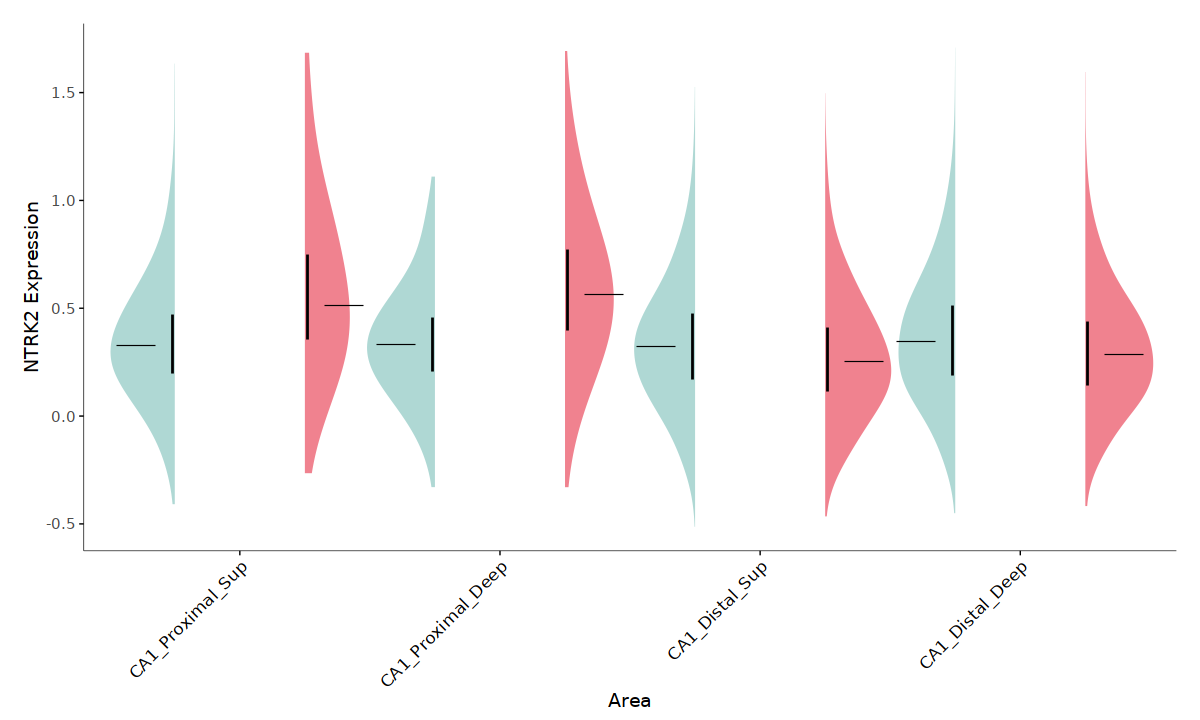

In [56]:
library(ggplot2) # 绘图
library(ggdist)  # 绘制概率分布
library(dplyr)   # 数据处理
library(Seurat)  # 单细胞数据处理



# 准备绘图数据
data.plot <- meta 
 data.plot$value = meta$NeuronDeath1
# 设置半眼图/小提琴图的水平偏移量
eye.moves <- 0.25

# 获取group的唯一值用于分配颜色
groups <- unique(data.plot$group)
if(exists("gp_color")) {
  group_colors <- gp_color[1:length(groups)]
  names(group_colors) <- groups
} else {
  # 如果gp_color不存在，使用默认颜色
  group_colors <- rainbow(length(groups))
  names(group_colors) <- groups
}

# 创建半分小提琴图
p <- ggplot()

# 为每个组绘制半眼图
for(i_group in 1:length(groups)) {
  current_group <- groups[i_group]
  current_color <- group_colors[current_group]
  
  # 左侧或右侧绘制
  side_position <- ifelse(i_group %% 2 == 1, 'left', 'right')
  x_offset <- ifelse(i_group %% 2 == 1, -eye.moves, eye.moves)
  
  # 绘制半眼图
  p <- p + 
    stat_eye(data = data.plot %>% filter(group == current_group),
             mapping = aes(x = area, y = value),
             side = side_position,
             point_color = NA,
             fill = current_color,
             alpha = 0.7,
             width = 0.29,
             .width = 0,
             adjust = 2,
             position = position_nudge(x = x_offset))
}

# 添加概率区间
for(i_group in 1:length(groups)) {
  current_group <- groups[i_group]
  x_offset <- ifelse(i_group %% 2 == 1, -eye.moves, eye.moves)
  adjustment <- ifelse(i_group %% 2 == 1, -0.01, 0.01)
  
  p <- p + 
    stat_eye(data = data.plot %>% filter(group == current_group),
             mapping = aes(x = area, y = value),
             point_color = NA,
             width = 0,
             .width = c(0.4),
             linewidth = 0.9,
             position = position_nudge(x = x_offset + adjustment))
}

# 添加中位数线
for(i_group in 1:length(groups)) {
  current_group <- groups[i_group]
  x_offset <- ifelse(i_group %% 2 == 1, -eye.moves, eye.moves)
  median_offset <- ifelse(i_group %% 2 == 1, -0.15, 0.15)
  
  p <- p + 
    stat_summary(data = data.plot %>% filter(group == current_group),
                 aes(x = area, y = value),
                 fun = median,
                 geom = "crossbar",
                 fatten = 0.5,
                 width = 0.15,
                 position = position_nudge(x = x_offset + median_offset))
}

# 添加主题和标签
p <- p +
  xlab("Area") +
  ylab(paste0(i, " Expression")) +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    panel.background = element_blank(),
    axis.text.x = element_text(size = 10, color = "black", angle = 45, hjust = 1),
    panel.border = element_blank(),
    axis.line = element_line(colour = "black", size = 0.15),
    plot.margin = unit(c(0.5,0.5,0.2,0.5),"cm"),
    axis.ticks = element_line(size = 0.3, color = "black")
  )

# 显示图形
print(p)

# 保存图形
ggsave(paste0(i, "_half_violin.pdf"), plot = p, width = 8, height = 4)


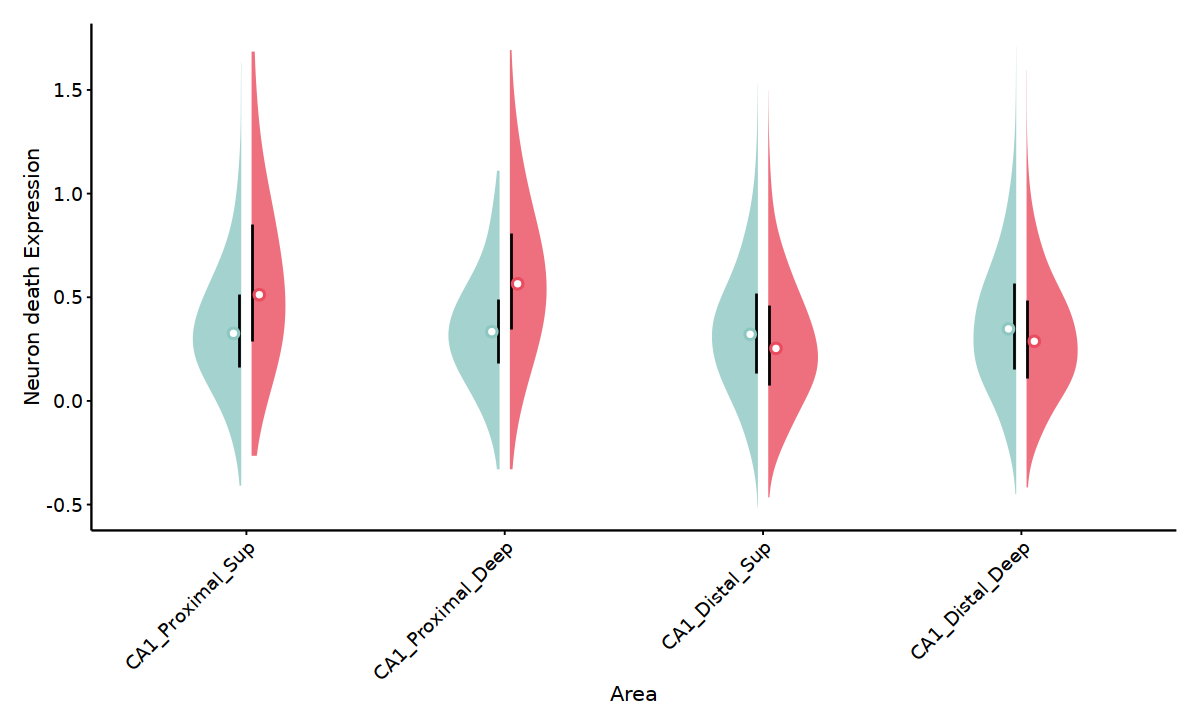

In [62]:
library(ggplot2) 
library(ggdist)  
library(dplyr)   

# 准备绘图数据
data.plot <- meta 
data.plot <- meta 
 data.plot$value = meta$NeuronDeath1
# 减小偏移量，解决间隔过远问题
eye.moves <- 0.02  # 从0.25减小到0.12

# 获取group的唯一值用于分配颜色
groups <- unique(data.plot$group)
if(exists("gp_color")) {
  group_colors <- gp_color[1:length(groups)]
  names(group_colors) <- groups
} else {
  # 使用更好的默认颜色
  default_colors <- c("#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", 
                     "#F39B7FFF", "#8491B4FF", "#91D1C2FF", "#DC0000FF")
  group_colors <- default_colors[1:length(groups)]
  names(group_colors) <- groups
}

# 创建半分小提琴图
p <- ggplot()

# 为每个组绘制半眼图
for(i_group in 1:length(groups)) {
  current_group <- groups[i_group]
  current_color <- group_colors[current_group]
  
  # 左侧或右侧绘制
  side_position <- ifelse(i_group %% 2 == 1, 'left', 'right')
  x_offset <- ifelse(i_group %% 2 == 1, -eye.moves, eye.moves)
  
  # 绘制半眼图
  p <- p + 
    stat_eye(data = data.plot %>% filter(group == current_group),
             mapping = aes(x = area, y = value),
             side = side_position,
             point_color = NA,
             fill = current_color,
             alpha = 0.8,
             width = 0.22,  # 从0.29减小到0.22
             .width = 0,
             adjust = 2,
             position = position_nudge(x = x_offset))
}

# 添加概率区间
for(i_group in 1:length(groups)) {
  current_group <- groups[i_group]
  x_offset <- ifelse(i_group %% 2 == 1, -eye.moves, eye.moves)
  adjustment <- ifelse(i_group %% 2 == 1, -0.005, 0.005)  # 从0.01减小到0.005
  
  p <- p + 
    stat_eye(data = data.plot %>% filter(group == current_group),
             mapping = aes(x = area, y = value),
             point_color = NA,
             width = 0,
             .width = c(0.5),  # 保持50%置信区间
             linewidth = 0.9,
             position = position_nudge(x = x_offset + adjustment))
}

# 添加中位数点（更紧凑）
for(i_group in 1:length(groups)) {
  current_group <- groups[i_group]
  current_color <- group_colors[current_group]
  x_offset <- ifelse(i_group %% 2 == 1, -eye.moves, eye.moves)
  median_offset <- ifelse(i_group %% 2 == 1, -0.03, 0.03)  # 从0.15减小到0.03
  
  p <- p + 
    stat_summary(data = data.plot %>% filter(group == current_group),
                 aes(x = area, y = value),
                 fun = median,
                 geom = "point",
                 color = current_color,
                 size = 2,
                 shape = 21,
                 fill = "white",
                 stroke = 1,
                 position = position_nudge(x = x_offset + median_offset))
}

# 添加主题和标签
p <- p +
  xlab("Area") +
  ylab(paste0("Neuron death Expression")) +
  theme_classic() +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    axis.text.x = element_text(size = 11, color = "black", 
                              angle = 45, hjust = 1, vjust = 1),
    axis.text.y = element_text(size = 11, color = "black"),
    axis.title = element_text(size = 12, color = "black"),
    plot.margin = unit(c(0.5,0.5,0.3,0.5),"cm"),
    axis.ticks = element_line(size = 0.4, color = "black"),
    axis.line = element_line(size = 0.5, color = "black")
  )

# 显示图形
print(p)

# 保存图形
ggsave(paste0(i, "_half_violin.pdf"), plot = p, width = 8, height = 5, dpi = 300)

## Fig3i-gene_exp

In [33]:
i = 'NTRK2'
seuobj@meta.data[,i] = seuobj@assays$RNA@data[i,]
meta1 = seuobj@meta.data

Warning message in max(meta$pathway_zscore, na.rm = TRUE):
“no non-missing arguments to max; returning -Inf”


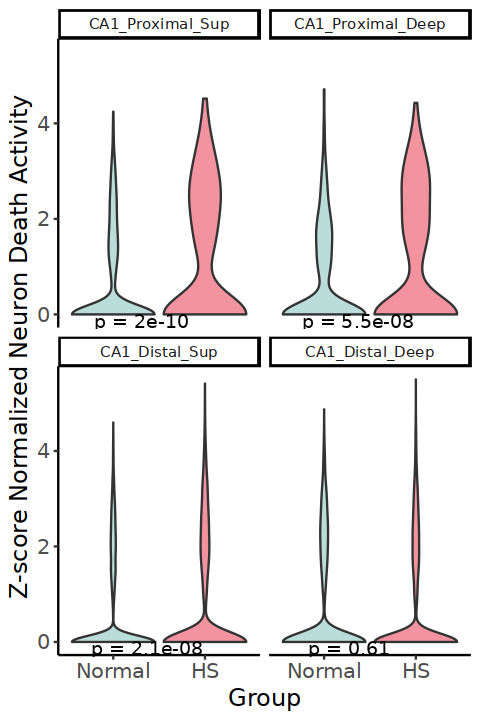

In [34]:
# 绘制小提琴图（使用Z-score标准化数据）
p = ggplot(meta1, aes(x = group, y = NTRK2, fill = group)) +
  geom_violin(
    alpha = 0.6, 
    width = 0.9,
    scale = "width",  # 统一最大宽度[1,3](@ref)
    trim = TRUE      # 保留密度曲线尾部[4](@ref)
  ) +
  # geom_boxplot(
  #   width = 0.1, 
  #   fill = "white",
  #   outlier.shape = NA  # 隐藏异常值
  # ) +
  scale_fill_manual(values = gp_color) +
  labs(
    x = "Group", 
    y = "Z-score Normalized Neuron Death Activity"
  ) +
  stat_compare_means(
    method = "wilcox.test",       # 或 "wilcox.test" 非参数检验[7](@ref)
    label = "p.format",      # 显示星号标记[8](@ref)
    label.y = max(meta$pathway_zscore, na.rm = TRUE) * 1.1  # 调整标签位置
  ) +
  theme_classic() +
  theme(
    legend.position = "none",  # 隐藏图例
    axis.text = element_text(size = 12),
    axis.title = element_text(size = 14)
  )+facet_wrap(~area)
# ggsave('NTRK2.vln.pvalue.pdf',p,width = 6,height = 6)
# getwd()
p

Warning message:
“The following variables were found in both object metadata and the default assay: NTRK2
Returning metadata; if you want the feature, please use the assay's key (eg. rna_NTRK2)”


[[1]]


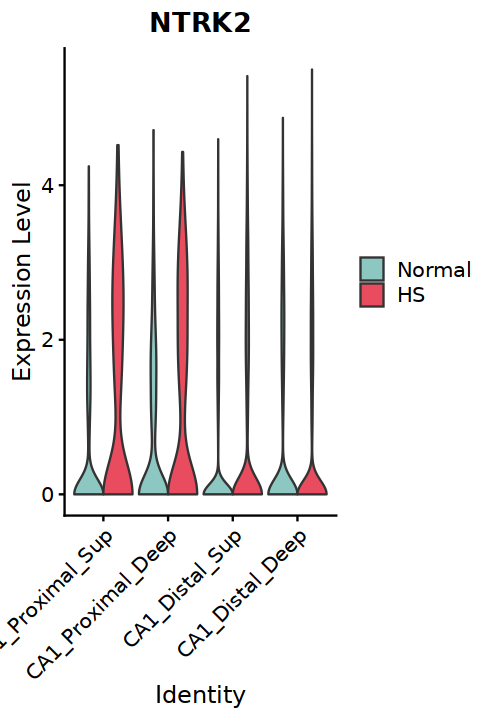

In [36]:
i = 'NTRK2'
seuobj@meta.data[,i] = seuobj@assays$RNA@data[i,]
meta1 = seuobj@meta.data
VlnPlot(seuobj, 
        feature = i,
        pt.size = 0,cols = gp_color ,
        group.by = "area",
        split.by = "group",
        combine = FALSE)